# Oppgave 3)

In [480]:
#INITIALISERING

#Importering
import numpy as np
from matplotlib import pyplot as plt
from scipy.special import erfc
import pandas as pd
from IPython.display import display

#konstanter
params_oppgave_3 = {
    "alfa"      : 0.8,
    "Tp"        : 500,
    "Nx"        : 100,
    "beta_k"    : 1000   
}
params_oppgave_3["L"] = 2*params_oppgave_3["Nx"]
params_oppgave_3["Np"] = 12*params_oppgave_3["Nx"]
params_oppgave_3["timeSteps"] = 20*params_oppgave_3["Tp"]

In [481]:
#HJELPEFUNKSJONER

#Potensialer
def V1(x, params):                #uten k fordi den inngår i p_pos
    Nx = params["Nx"]
    alfa = params["alfa"]
    periode = x % Nx

    if periode <= alfa*Nx:
        return periode/(alfa*Nx)
    else:
        return (Nx-periode)/((1-alfa)*Nx)

def V2(x, params):                       
    return 0                       


#Sannsynlighetsfunksjoner p+ og p-
def p_pos(x, V, params):
    beta_k = params["beta_k"]
    L = params["L"]

    arg1 = np.clip(-beta_k*(V((x-1)%L,params)-V((x+1)%L,params)), -700, 700)
    arg2 = np.clip(-beta_k*(V(x%L,params)-V((x+1)%L,params)), -700, 700)

    nevner = 1  + np.exp(arg1) \
                + np.exp(arg2)

    return 1/nevner

def p_neg(x, V, params):
    beta_k = params["beta_k"]
    L = params["L"]

    arg1 = np.clip(-beta_k*(V((x+1)%L,params)-V((x-1)%L,params)), -700, 700)
    arg2 = np.clip(-beta_k*(V(x%L,params)-V((x-1)%L,params)), -700, 700)

    nevner = 1  + np.exp(arg1) \
                + np.exp(arg2)
    return 1/nevner


#Look-up tabeller for raskere kjøring
def lookUpTabell_V1(params):
    L = params["L"]

    tabell_V1_p_pos = np.zeros(L)
    tabell_V1_p_neg = np.zeros(L)

    for x in range(L):
        tabell_V1_p_pos[x] = p_pos(x, V1, params)
        tabell_V1_p_neg[x] = p_neg(x, V1, params)

    return tabell_V1_p_pos, tabell_V1_p_neg

def lookUpTabell_V2(params):
    L = params["L"]

    p_pos_val = p_pos(1, V2, params)
    p_neg_val = p_neg(1, V2, params)

    tabell_V2_p_pos = np.full(L, p_pos_val)
    tabell_V2_p_neg = np.full(L, p_neg_val)

    return tabell_V2_p_pos, tabell_V2_p_neg


#oppgave 3a hjelpefunksjoner
def syklusSnitt(current, params):
    syklus_len = 2*params["Tp"]
    n_cycles = len(current)//syklus_len
    return np.arange(1, n_cycles+1), np.array([current[n*syklus_len:(n+1)*syklus_len].mean() for n in range(n_cycles)])

def init_partikler_3a(params):
    L = params["L"]
    return np.repeat(np.arange(0,L), 6)


#oppgave 3b hjelpefunksjoner
def init_partikler_3b(params):
    Nx = params["Nx"]
    Np = params["Np"]
    return np.repeat([0,Nx], Np//2)


#oppgave 3c hjelpefunksjoner
def init_partikler_3c(params):
    Np = params["Np"]
    return np.zeros(Np, dtype=int)


In [482]:
#SIMULERINGSFUNKSJONER

#oppgave 3 generelt
def particleCurrent_sim(partiklerPos, params, tabeller):
    timeSteps = params["timeSteps"]
    Tp = params["Tp"]
    L = params["L"]
    Np = params["Np"]
    startPot_pos_table = tabeller["startPot_pos_table"]
    startPot_neg_table = tabeller["startPot_neg_table"]
    secondPot_pos_table = tabeller["secondPot_pos_table"]
    secondPot_neg_table = tabeller["secondPot_neg_table"]

    particleCurrent = np.zeros(timeSteps)

    for k in range(timeSteps):
        hvilkenPotensial = ( k // Tp) % 2    
        n_pos = 0
        n_neg = 0
        if hvilkenPotensial == 0:
            tabell_p_pos, tabell_p_neg = startPot_pos_table, startPot_neg_table
        else:
            tabell_p_pos, tabell_p_neg = secondPot_pos_table, secondPot_neg_table
        
        randomtabell = np.random.rand(Np)

        posProb = tabell_p_pos[partiklerPos]
        negProb = tabell_p_neg[partiklerPos]

        neg_flytt = (randomtabell <= negProb)
        pos_flytt = (~neg_flytt) & (randomtabell >= (1 - posProb))

        partiklerPos[neg_flytt] -= 1
        partiklerPos[pos_flytt] += 1
        partiklerPos %= L

        n_pos = pos_flytt.sum()
        n_neg = neg_flytt.sum()
        particleCurrent[k] = (n_pos - n_neg)/Np

    return particleCurrent

In [483]:
#OPPGAVEFUNKSJONER

#oppgave 3a
def oppgave_3a(params):
    lokal_params = params.copy()
    partiklerPos = init_partikler_3a(params = lokal_params)

    tabell_V1_p_pos, tabell_V1_p_neg = lookUpTabell_V1(params = lokal_params)
    tabell_V2_p_pos, tabell_V2_p_neg = lookUpTabell_V2(params = lokal_params)

    tabeller_potensial_3a = {
        "startPot_pos_table" : tabell_V2_p_pos,
        "startPot_neg_table" : tabell_V2_p_neg,
        "secondPot_pos_table": tabell_V1_p_pos,
        "secondPot_neg_table": tabell_V1_p_neg
    }

    particleCurrent = particleCurrent_sim(partiklerPos, params = lokal_params, tabeller = tabeller_potensial_3a)
    
    particleCurrent_syklusSnitt = syklusSnitt(particleCurrent, params = lokal_params)

    return particleCurrent_syklusSnitt


#oppgave 3b
def oppgave_3b(params):
    lokal_params = params.copy()
    lokal_params["Np"] = 40*lokal_params["Nx"]

    tabell_V1_p_pos, tabell_V1_p_neg = lookUpTabell_V1(params = lokal_params)
    tabell_V2_p_pos, tabell_V2_p_neg = lookUpTabell_V2(params = lokal_params)

    tabeller_potensial_3b = {
        "startPot_pos_table" : tabell_V2_p_pos,
        "startPot_neg_table" : tabell_V2_p_neg,
        "secondPot_pos_table": tabell_V1_p_pos,
        "secondPot_neg_table": tabell_V1_p_neg
    }

    Tp_array = np.round(np.linspace(1, 1001, 50)).astype(int)
    resultatarray = np.zeros(len(Tp_array))

    for i in range(len(Tp_array)):
        lokal_params["Tp"] = Tp_array[i]
        lokal_params["timeSteps"] = 2*lokal_params["Tp"]
        partiklerPos = init_partikler_3b(lokal_params)

        particleCurrent = particleCurrent_sim(partiklerPos, params = lokal_params, tabeller = tabeller_potensial_3b)

        resultatarray[i] = particleCurrent.mean()

    return Tp_array, resultatarray


#oppgave 3c
def oppgave_3c(params):
    lokal_params = params.copy()
    lokal_params["Tp"] = 500
    lokal_params["Np"] = 12*lokal_params["Nx"]
    lokal_params["timeSteps"] = 2*lokal_params["Tp"]

    alfa_array = np.linspace(0.01,1-0.01, 50)
    resultatarray = np.zeros(len(alfa_array))

    for i in range(len(alfa_array)):
        lokal_params["alfa"] = alfa_array[i]
        partiklerPos = init_partikler_3c(params = lokal_params)

        tabell_V1_p_pos, tabell_V1_p_neg = lookUpTabell_V1(lokal_params)
        tabell_V2_p_pos, tabell_V2_p_neg = lookUpTabell_V2(lokal_params)

        tabeller_potensial_3c = {
            "startPot_pos_table" : tabell_V2_p_pos,
            "startPot_neg_table" : tabell_V2_p_neg,
            "secondPot_pos_table": tabell_V1_p_pos,
            "secondPot_neg_table": tabell_V1_p_neg
        }
        particleCurrent = particleCurrent_sim(partiklerPos, params = lokal_params, tabeller = tabeller_potensial_3c)
        resultatarray[i] = particleCurrent.mean()
    
    Tp = lokal_params["Tp"]
    Nx = lokal_params["Nx"]

    analytisk_3c_array = (Nx/(4*Tp))*(erfc((alfa_array*Nx/2)*np.sqrt(3/Tp)) - erfc(((1-alfa_array)*Nx/2)*np.sqrt(3/Tp)))

    return alfa_array, resultatarray, analytisk_3c_array


#oppgave 3d
def oppgave_3d(params):
    lokal_params = params.copy()
    lokal_params["Tp"] = 500
    lokal_params["Np"] = 12*lokal_params["Nx"]
    lokal_params["timeSteps"] = 2*lokal_params["Tp"]

    alfa_array = np.linspace(0.01,1-0.01, 50)
    beta_k_array = np.array([0.01, 1, 2, 3, 5, 10])
    resultatarray = np.zeros((len(beta_k_array), len(alfa_array)))

    for k in range(len(beta_k_array)):
        lokal_params["beta_k"] = beta_k_array[k]
        mdltr_resultatarray = np.zeros(len(alfa_array))

        for i in range(len(alfa_array)):
            lokal_params["alfa"] = alfa_array[i]
            partiklerPos = init_partikler_3c(params = lokal_params)

            tabell_V1_p_pos, tabell_V1_p_neg = lookUpTabell_V1(lokal_params)
            tabell_V2_p_pos, tabell_V2_p_neg = lookUpTabell_V2(lokal_params)

            tabeller_potensial_3d = {
                "startPot_pos_table" : tabell_V2_p_pos,
                "startPot_neg_table" : tabell_V2_p_neg,
                "secondPot_pos_table": tabell_V1_p_pos,
                "secondPot_neg_table": tabell_V1_p_neg
            }
            particleCurrent = particleCurrent_sim(partiklerPos, params = lokal_params, tabeller = tabeller_potensial_3d)
            mdltr_resultatarray[i] = particleCurrent.mean()
        resultatarray[k, :] = mdltr_resultatarray

    Nx = lokal_params["Nx"]
    Tp = lokal_params["Tp"]

    analytisk_3d_array = (Nx/(4*Tp))*(erfc((alfa_array*Nx/2)*np.sqrt(3/Tp)) - erfc(((1-alfa_array)*Nx/2)*np.sqrt(3/Tp)))
    
    return alfa_array, resultatarray, analytisk_3d_array


#oppgave 3e
def oppgave_3e(params):
    lokal_params = params.copy()
    lokal_params["Nx"] = 10
    lokal_params["Np"] = 40*lokal_params["Nx"]
    lokal_params["alfa"] = 0.8

    tabell_V1_p_pos, tabell_V1_p_neg = lookUpTabell_V1(params = lokal_params)
    tabell_V2_p_pos, tabell_V2_p_neg = lookUpTabell_V2(params = lokal_params)

    tabeller_potensial_3e = {
        "startPot_pos_table" : tabell_V2_p_pos,
        "startPot_neg_table" : tabell_V2_p_neg,
        "secondPot_pos_table": tabell_V1_p_pos,
        "secondPot_neg_table": tabell_V1_p_neg
    }

    Tp_array = np.round(np.linspace(80, 1500, 20)).astype(int)
    resultatarray = np.zeros(len(Tp_array))

    for i in range(len(Tp_array)):
        lokal_params["Tp"] = Tp_array[i]
        lokal_params["timeSteps"] = 2*lokal_params["Tp"]
        partiklerPos = init_partikler_3b(lokal_params)

        particleCurrent = particleCurrent_sim(partiklerPos, params = lokal_params, tabeller = tabeller_potensial_3e)

        resultatarray[i] = particleCurrent.mean()
    
    Nx = lokal_params["Nx"]
    alfa = lokal_params["alfa"]

    analytisk_3e_array = (Nx/(4*Tp_array))*(erfc((alfa*Nx/2)*np.sqrt(3/Tp_array)) - erfc(((1-alfa)*Nx/2)*np.sqrt(3/Tp_array)))

    return Tp_array, resultatarray, analytisk_3e_array

In [484]:
#PLOTTEFUNKSJONER

#oppgave 3a
def plot_oppgave_3a(params, alfa=None):
    lokal_params = params.copy()

    if alfa is not None:
        lokal_params["alfa"] = alfa

    syklus_array, particleCurrent_3a = oppgave_3a(lokal_params)

    plt.figure(figsize=(8,4))
    plt.plot(syklus_array, particleCurrent_3a, marker="o", markersize=4)
    plt.axhline(0, color="black", linewidth=1, alpha=0.4)
    plt.xlim(1, syklus_array[-1])

    plt.xlabel(r"syklusnummer")
    plt.ylabel(r"$J_{avg}$ per syklus")
    plt.title(r"Oppgave 3a: gjennomsnittlig partikkelstrøm som funksjon av syklus")
    plt.grid(alpha=0.3)

    plt.show()
    df = pd.DataFrame({"syklus n": syklus_array, "J_avg(n)": particleCurrent_3a})
    display(df)


#oppgave 3b
def plot_oppgave_3b(params):
    Tp_array, particleCurrent_3b = oppgave_3b(params)
    
    plt.figure(figsize=(8,4))
    plt.plot(Tp_array, particleCurrent_3b)

    plt.xlabel(r"$T_p$")
    plt.ylabel(r"$J_{avg}$")
    plt.title(r"Oppgave 3b: gjennomsnittlig partikkelstrøm som funksjon av $T_p$")
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


#oppgave 3c
def plot_oppgave_3c(params):
    alfa_array, particleCurrent_3c, analytisk_3c_array = oppgave_3c(params)

    plt.figure(figsize=(8,4))
    plt.plot(alfa_array, particleCurrent_3c, label="simulering")
    plt.plot(alfa_array, analytisk_3c_array, "k--", label="analytisk", alpha = 0.6)

    plt.xlabel(r"$\alpha$")
    plt.ylabel(r"$J_{\mathrm{avg}}$")
    plt.title(r"Oppgave 3c: gjennomsnittlig partikkelstrøm som funksjon av $\alpha$")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show() 


#oppgave 3d
def plot_oppgave_3d(params):
    alfa_array, particleCurrent_3d, analytisk_3d_array = oppgave_3d(params)

    beta_k_array = np.array([0.01, 1, 2, 3, 5, 10])

    plt.figure(figsize=(10,5))

    for beta_k, current in zip(beta_k_array, particleCurrent_3d):
        plt.plot(alfa_array, current, label=rf"$\beta k = {beta_k}$")

    plt.plot(alfa_array, analytisk_3d_array, "k--", label="analytisk", alpha = 0.6)

    plt.xlabel(r"$\alpha$")
    plt.ylabel(r"$J_{\mathrm{avg}}$")
    plt.title(r"Oppgave 3d: gjennomsnittlig partikkelstrøm som funksjon av $\alpha$")
    plt.grid(alpha=0.3)

    handles, labels = plt.gca().get_legend_handles_labels()

    plt.legend(handles[::-1], labels[::-1],
               bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()


# oppgave 3e
def plot_oppgave_3e(params):
    Tp_array, particleCurrent_3e, analytisk_3e_array = oppgave_3e(params)

    plt.figure(figsize=(8,4))

    plt.plot(Tp_array, particleCurrent_3e, label="simulering")
    plt.plot(Tp_array, analytisk_3e_array, "--", color="gray", label="analytisk")

    plt.xlabel(r"$T_p$")
    plt.ylabel(r"$J_{\mathrm{avg}}$")
    plt.title(r"Oppgave 3e: gjennomsnittlig partikkelstrøm som funksjon av $T_p$")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## Oppgave 3a)

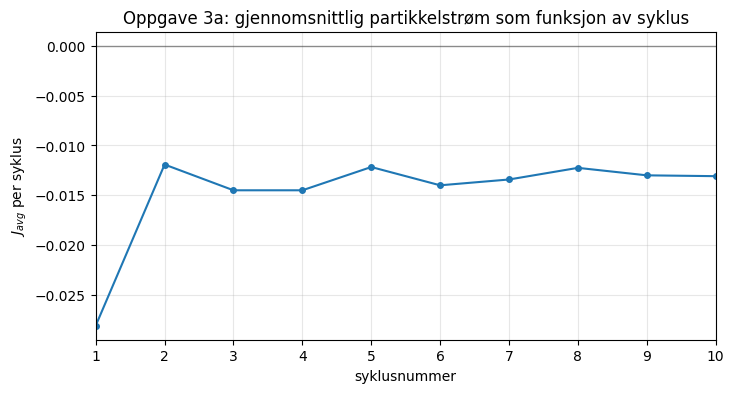

,syklus n,J_avg(n)
0,1,-0.028083
1,2,-0.011917
2,3,-0.014500
3,4,-0.014500
4,5,-0.012167
5,6,-0.014000
6,7,-0.013417
7,8,-0.012250
8,9,-0.013000
9,10,-0.013083


In [485]:
plot_oppgave_3a(params_oppgave_3)

#### 3a, $\alpha = 0.8$)

#### Hvorfor får vi non-zero strømning?

Som man kan observere i grafen og tabellen over ligger alle $J_{\text{avg}}$ verdier under -0.010. Årsaken til dette ligger i at man tar gjennomsnittet av partikkelstrømmen over en periode $2T_p$ hvor første halvperiode $T_p$ har potensialet $V_2(x) = k$ og den andre halvperioden

$$
V_1(x)=
\begin{cases}
\dfrac{kx}{\alpha N_x}, & 0 < x \le \alpha N_x \\
-\dfrac{kx}{(1-\alpha)N_x}, & -(1-\alpha)N_x < x \le 0
\end{cases}
$$

som er den periodiske funksjonen. Hvis man kun hadde tatt gjennomsnittet under $V_2$ potensialet ville man forvente å få i snitt en $J_{\text{avg}} = 0$ ettersom dette potensialet gir at $p_{\text{neg}} = p_{0} = p_{\text{pos}} = \frac{1}{3}$, noe som gir tilfeldig virrevandring uten strøm i en spesiell retning. Under halvperioden med $V_2$ blir derimot ikke sannsynlighetene like, men $p_{\text{neg}}$ størst. En intuitiv forklaring på hvorfor det blir slik kan man få av å tenke over hvordan potensialfunksjonen $V_1$ ser ut. En heuristisk regel, som vi skal prøve å underbygge litt mere snart, er at hvis en partikkel er i et potensialfelt vil den mest sannsynlig bevege seg i den retningen som tilsvarer at potensialet faller. Med $\alpha = 0.8$ blir dermed områder som modulo tilsvarer $(0, 0.8N_x]$, en positiv helning, som ettersom partikler beveger seg ned potensialet fører til at de går mot venstre. Samtidig tilsvarer områder som modulo tilsvarer $(0.8N_x, N_x]$ en negativ helning som fører til at partikler beveger seg mot høyre (mest sannsynlig). Ettersom området med positiv helning er større en området med negativ helning forventer man dermed i snitt en negativ strømning under potensialet $V_1$. Hvis man tenker seg at partiklene er tilfeldig plassert forventer man dermed at omtrent $80\%$ av partiklene beveger seg mot venstre mens $20\%$ beveger seg til høyre, noe som i snitt gir at rundt $60\%$ av partikler beveger seg mot venstre.

Grunnen til at vi kan bruke dette heuristiske argumentet om at partikler beveger seg nedover potensialet kommer fra hvordan sannsynlighetene regnes ut. I uttrykket for $p_{\text{pos}}$ opptrer det ledd i nevneren som inneholder eksponentialer av potensialforskjeller på formen $e^{-\beta (V(x_{\text{venstre}})-V(x_{\text{høyre}}))}$. I områder der potensialet har positiv helning vil $V(x_{\text{høyre}}) > V(x_{\text{venstre}})$. Dermed blir forskjellen $V(x_{\text{venstre}})-V(x_{\text{høyre}})$ negativ. 
Når dette multipliseres med $-\beta k = 1000$ (trakk ut k fra V(x) her) blir eksponenten positiv og stor, slik at eksponentialleddet blir svært stort. 
Siden dette står i nevneren i uttrykket for $p_{\text{pos}}$, fører det til at $p_{\text{pos}}$ blir svært liten. Sannsynligheten $p_0$ inneholder også et slikt eksponentialledd i nevneren. Dermed blir også $p_0$ liten i områder med positiv stigning, men den vil fortsatt være større enn $p_{\text{pos}}$. For $p_{\text{neg}}$ opptrer potensialforskjellen derimot med motsatt fortegn, slik at eksponenten blir negativ. Eksponentialleddet blir da svært lite, noe som gjør at bidraget til nevneren blir lite og sannsynligheten $p_{\text{neg}}$ derfor blir størst i områder der potensialet har positiv helning. Tilsvarende får man motsatt situasjon i områder der potensialet har negativ helning, hvor $p_{\text{pos}}$ blir den største sannsynligheten. Dette stemmer også med den fysiske intuisjonen om at partiklene foretrekker å bevege seg nedover i potensialet.

#### Sammenligning mellom $J_{\text{avg}}(0)$ og $J_{\text{avg}}(n)$, ($n > 0$)

Som man ser i grafen over ligger $J_{\text{avg}}(0)$ omtrent rundt -0.03, mens $J_{\text{avg}}(n)$, ($n > 0$) ser ut til å stabilisere seg rundt omtrent -0.015 allerede ved $n = 1$. Det tyder dermed på at $|J_{\text{avg}}|$ er størst i begynnelsen av simulasjonen. Grunnen til dette kan være at i initialposisjonen så er alle partiklene jevnt fordelt overalt, og etter første halvperiode $T_p$ vil de dermed fortsatt være omtrent jevnt fordelt, bare med litt mere støy. Det betyr at når andre halvperiode nå begynner $[T_p, 2T_p)$ vil omtrent $80\%$ av partikler befinne seg i områder med positiv helning ettersom $80\%$ av intervallet har positiv helning, som vil føre til at de vil bidra til en negativ strøming. Ettersom en $N_x = 100$ og $T_p = 500$ vil partiklene under $V_1$ ha mer enn nok tid til å ta nok steg til å lokalisere seg rundt nullpunkt som er i punkter hvor $x \bmod N_x = 0$. Det vil si at de vil innstille seg en tilnærmet likevektsstilling før denne halvperioden er ferdig. Når neste halvperiode begynner $[2T_p, 3T_p)$ er vi tilbake til $V_2$ potensialet og får tilfeldig virrevandring. Etter denne halvperioden vil partiklene ha beveget seg litt utover, men siden vandringen var tilfeldig i alle retninger vil de fortsatt ha størst forventningsverdi til å være lokalisert der de sluttet sist, altså ved nullpunktene. Når da neste halvperiode begynner $[3T_p, 4T_p)$ vil det dermed i snitt være flere partikler lokalisert rundt nullpunktene, og ettersom partikler ved nullpunkter ikke beveger seg forventer vi dermed å få en lavere strømning, noe vi også observerer. Grunnen til at vi fortatt observerer negativ strømning her likevel er det at ettersom partiklene beveger seg i snitt like ofte til venstre som til høyre under $V_2$ vil det ha vært i snitt like mange partikler til venstre som til høyre etter halvperioden $[2T_p, 3T_p)$. Gitt at hvertfall noen av disse partiklene beveger seg en avstand lenger enn $0.2N_x$ fra nullpunktet under denne halvperioden, vil disse partiklene ha større sannsynlighet for å befinne seg i et område som tilsvarer positiv helning ettersom i avstander lenger enn $0.2N_x$ fra nullpunkter vil prosentandelen område med positiv helning øke, som dermed vil føre til negativ strømning.

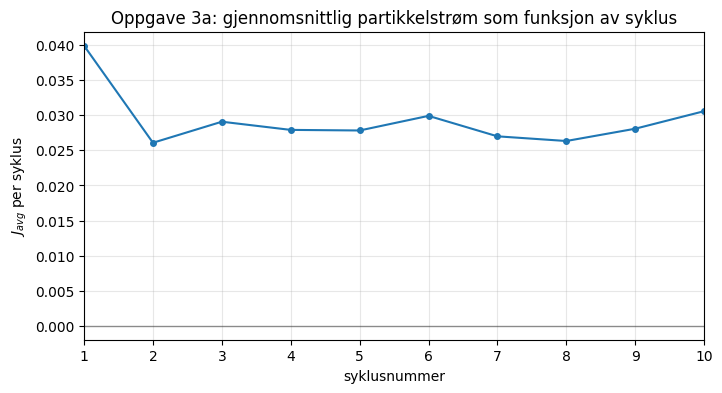

,syklus n,J_avg(n)
0,1,0.039917
1,2,0.026083
2,3,0.029083
3,4,0.027917
4,5,0.027833
5,6,0.029917
6,7,0.027000
7,8,0.026333
8,9,0.028083
9,10,0.030583


In [486]:
plot_oppgave_3a(params_oppgave_3, alfa = 0.1)

#### 3a, $\alpha = 0.1$)

For å unngå unødvendig gjentakelse gjør vi en kortere analyse for $\alpha = 0.1$, og fokuserer på forskjellene sammenlignet med resultatene for $\alpha = 0.8$. 

#### Hvorfor får vi non-zero strømning?

Situasjonen er lik som ved $\alpha = 0.8$ og vi får også non-zero strømnig her. Den eneste forskjellen her er at med $\alpha = 0.1$ vil potensialfunksjonen ha negativ helning i områder hvor $x \bmod N_x $ ligger i intervallet $(0.1N_x, N_x]$ Dette innebærer at nå vil $90\%$ av området partikler kan ligge i ha negativ helning på potensialfunksjonen, som vil føre til en positiv strøming mot høyre. Så likens som istad vil omtrent $90\%$ av partikler bevege seg mot høyre, mens $10\%$ mot venstre, som i snitt gir $80\%$ strøming mot høyre hvis partikler blir tilfeldig plassert på området.

#### Sammenligning mellom $J(0)$ og $J(n)$, ($n > 0$)

For $\alpha = 0.8$ var $J_{\text{avg}}(0) \approx -0.03$, mens for $\alpha = 0.1$ blir $J_{\text{avg}}(0) \approx 0.038$ Dette tyder på at absoluttverdien i strøming er strørre for $\alpha = 0.1$. Dette stemmer ganske godt med at det er en større prosentandel av området som har negativ helning, som dermed vil føre til at det blir mere strømning mot høyre. Man ser også i plottet for $\alpha = 0.1$ at det ser ut som at $J_{\text{avg}}(n)$ ser ut til å stabilisere seg rundt $0.028$. Dette er også større i absoluttverdi enn for $\alpha = 0.8$. Grunnen til dette kan være at nå må partiklene kun bevege seg en avstand på $0.1N_x$ fra nullpunktet før sannsynligheten for at de ligger på et område som tilsvarer strøming mot høyre er større enn sannsynligheten for å ligge på et område som tilsvarer strømning mot venstre. Dette vil da føre til at under halvperioder med $V_2$ vil tilfeldig virrevandring føre til at flere partikler vil befinne seg i høyregående områder enn ved $\alpha = 0.8$.

# Oppgave 3b)

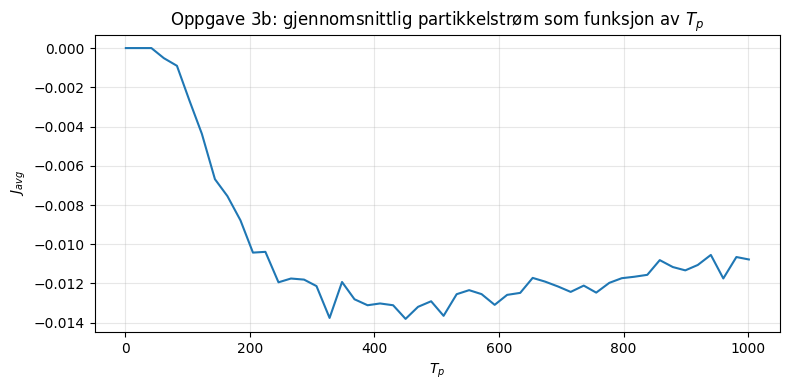

In [487]:
plot_oppgave_3b(params_oppgave_3)

Som man ser i grafen over er gjennomsnittlig partikkelstrøm ved lave verdier av $T_p \approx 0$. Deretter øker $|J_{\text{avg}}|$ som $T_p$ øker, og når et maximum rundt $T_p \approx 500$ før den igjen begynner å synke utover mot $T_p = 1000$. Grunnen til at $T_p \approx 0$ ved lave verdier av $T_p$ er mest sannsynlig fordi partiklene ikke får nok tid til å diffundere ut under $V_2$ potensial-halvperioden. Ettersom partiklene starter i nullpunktene vil de under $V_2$ bevege seg i snitt like mye til venstre som til høyre. Dersom $T_p$ er mindre enn $0.2Nx = 20$ vil ingen partikler ha nok steg til å bevege seg forbi fra en helning til neste helning til potensialfunksjon. Altså ingen partikler vil ha muligheten å gå fra et nullpunkt til nærmeste sted hvor potensialet går fra å ha positiv helning til å ha negativ helning, eller motsatt. Eksempelvis vil en partikkel i $x = N_x$ ha nærmeste ratchet-grense i $0.8Nx$, som er $20$ steg unna. Hvis partikkelen holder seg innenfor 20 steg fra nullpunktet vil dermed sannsynligheten for å havne i et område med positiv helning være lik sannsynligheten for å havne i et område med negativ helning. Det fører dermed til at partiklene i snitt vil bevege seg like mye mot høyre som venstre når $V_1$ potensial-halvperioden begynner.

Dersom derimot partiklene får nok tid til å ta nok steg, vil sannsynligheten for å havne i et område med negativ helning være større enn å havne i positiv helning (for $\alpha = 0.8$). Eksempelvis vil det være slik at hvis partiklene har nok steg til å flytte seg akkurat slik at de kan være innenfor en avstand på $0.8N_x$ vil sannsynligheten for å havne på et område med negativ helning være $\frac{0.8N_x + 0.6N_x}{1.6N_x} = 87.5\%$. Her har vi faktisk gjort en litt for grov forenkling å antatt at at partiklene blir uniformt fordelt under $V_2$ perioden, som ikke stemmer. Prisnippet er likevel det samme bare med en tilnærmet normalfordeling innenfor området. Det innebærer dermed at det finnes en maksimum verdi når sannsynligheten for å lande i et område som fører til venstre-vandring er størst.

Hvis partiklene får for mange steg derimot vil sannsynligheten for å havne på et område som fører til venste-vandring under $V_2$ gå mot $80\%$, ettersom det er andelen av område som har denne ratchet-potensialet. Det går dermed altså mot en tilnærmet uniform fordeling under $V_2$ halvperioden som vil føre til $|J_{\text{avg}}|$ vil minke sammenlignet med når den var middels stor.

# Oppgave 3c)

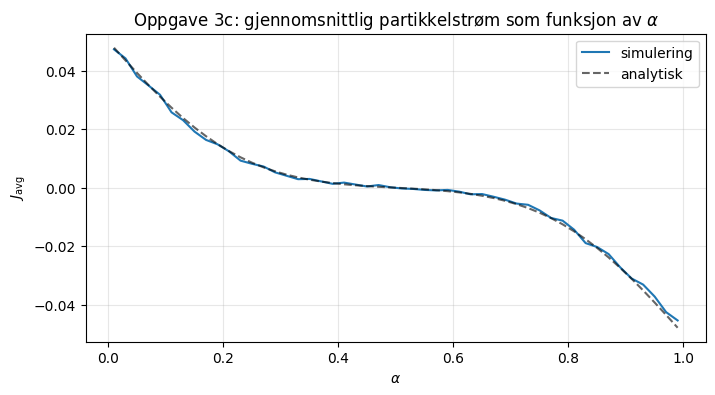

In [488]:
plot_oppgave_3c(params_oppgave_3)

I grafen over ser man enda bedre hvordan verdien av $\alpha$ påvirker gjennomsnittlig partikkelstrøm. Som man ser vil verdier av $\alpha$ under 0.5 føre til positive verdier av $J_{\text{avg}}$ gjennom at en større del av området partikler kan befinne seg i vil ha at potensialfunksjon har negativ helning. Motsatt vil verdier av $\alpha$ over 0.5 føre til negativ gjennomsnittlig partikelstrøm, da det blir en større del av området med positiv helning på potensialfunksjonen. Når $\alpha = 0.5$ vil potensialfunksjonen være symmetrisk rundt nullpunktene, noe som gir like mye strøming i hver retning, som forklarer hvorfor vi observerer $J_{\text{avg}} \approx 0$ her. Vi observerer også at grafen er antisymmetrisk rundt $\alpha = 0.5$. Dette betyr at $J_{\text{avg}}(\alpha) = -J_{\text{avg}}(1 - \alpha)$. Dette skyldes at ratchet-potensialet for ${(1 - \alpha)}$ er speilbildet av potensialet for ($\alpha$). Et intuitivt bilde man kan ha her er hvis man tenker på potensialfunksjonen som et landskap og partiklene som baller som ruller ned bakken. Jo større andel av bakker som går nedover mot venstre, jo mere negativ strøming får vi og motsatt hvis vi har en større andel bakker som går nedover mot høyre. Vi observerer også i grafen at simuleringen samsvarer ganske godt med den analytiske løsningen for gjennomsnittlig partikkelstrøming her. Årsaken til dette ligger i at $\beta k = 1000$ gir en tilnærmet deteministisk bevegelse ut ifra hvilken bakke man befinner seg i, altså at partiklene nesten garantert går ned bakken. Dette kommer vi tilbake til i oppgave 3f).

# Oppgave 3d)

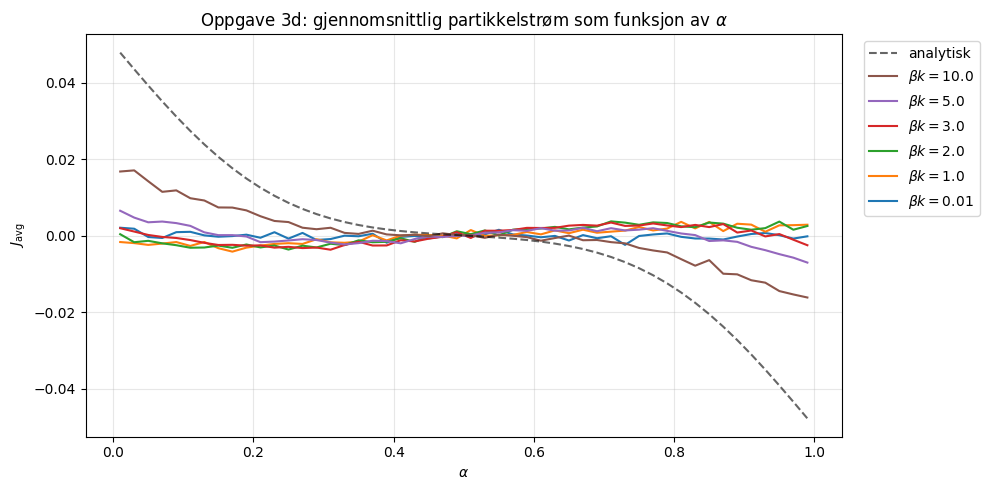

In [489]:
plot_oppgave_3d(params_oppgave_3)

I grafen over ser man hvordan lavere verdier av $\beta k$ ikke samsvarer like godt med den analytiske løsningen. Som man ser gir $\beta k = 10.0$ størst utslag ved lave og store verdier av $\alpha$, mens $\beta k = 0.01$ gir minst. Som vi så i oppgave 3d) var $\beta k = 1000$ tilnærmet ganske lik den analytiske løsningen, som også tyder på at lavere verdier av $\beta k$ fører til grafer som ligger nærmere $J_{\text{avg}}(\alpha) = 0$. Grunnen til dette ligger i at ved lavere verdier av $\beta k$ blir helningen til potensialfunksjonen $V_1$ mindre, som fører til at vi ikke lenger får en dominant $p_{\text{neg}}$ eller $p_{\text{pos}}$. Bevegelsen til partiklene blir dermed mindre deterministisk og når $\beta k \to 0$ nærmer vi oss tilfeldig virrevanding hvor $J_{\text{avg}}(\alpha) = 0$. Dette kan fysisk forstås ved at høy temperatur fører til større termiske fluktuasjoner, slik at partiklene sprer seg mer tilfeldig i rommet ($\beta k \to 0$ er ekvivalent med at $T \to \infty$).

# Oppgave 3e)

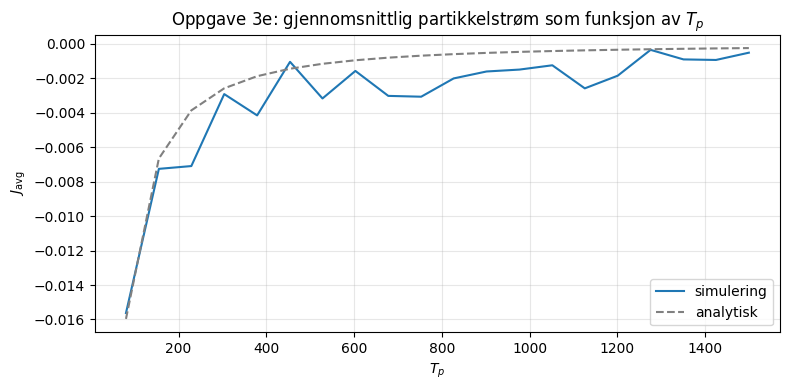

In [490]:
plot_oppgave_3e(params_oppgave_3)

I grafen over ser man hvordan gjennomsnittlig partikkelstrøm endrer seg som funksjon av $T_p$ slik som i oppgave 3b) bare at i denne simuleringen så er bredden $N_x = 10$ mindre. Som man ser er partikkelstrømmen $|J_{\text{avg}}|$ størst ved lave verdier av $T_p$, men blir mindre når $T_p$ øker. Ettersom $N_x$ nå er mindre kan partiklene komme seg lenger unna nullpunktene når $V_2$ potensialet skrur seg på. Som man ser er $|J_{\text{avg}}|$ størst ved lave verdier av $T_p$, og avtar når $T_p$ øker. Siden $N_x$ er mindre, vil partiklene allerede ved relativt små verdier av $T_p$ kunne diffundere en betydelig del av potensialperioden $V_2$. Dermed tilsvarer $T_p = 80$ i dette systemet omtrent mye større verdier av $T_p$ i oppsettet fra oppgave 3b), hvor potensialperioden var $N_x = 100$, altså ti ganger større. Det vil si at grafen vi ser her er allerede forbi sitt $|J_{\text{avg}}|$ maksimumspunkt, og vil bare synke videre. Grunnen til at den simulerte grafen nærmer seg 0 ved enda større verdier av $T_p$ er fordi partiklene lokaliserer seg ved nullpunktene og slutter å flytte på seg resten av den halvperioden ($(T_p, 2T_p)$), dermed bidrar ikke dette lenger til strømning, men man deler fortsatt på $T_p$ som er større, som betyr at $|J_{\text{avg}}|$ blir mindre. 

Man kan også observere at den analytiske løsningen ligger ganske godt sammen med den simulerte løsnigen, men at den ser ut til å ligge litt høyere større verdier av $T_p$. Grunnen til dette kan ligge 

# Oppgave 3f)

SKRIVEOPPGAVE